In [2]:
library(ape)
library(TreeSim)
library(RColorBrewer)

### 1. Felsenstein's worst scenario

In [3]:
s1 = stree(10, type = "star")
s2 = stree(10, type = "star")

s1$tip.label = paste(s1$tip.label,"_1")
s2$tip.label = paste(s2$tip.label,"_2")

s1$edge.length=rep(1,length(s1$tip.label))
s2$edge.length=rep(1,length(s2$tip.label))

s1$root.edge=10
s2$root.edge=10

combined_tree = s1 + s2

In [4]:
n_tips = length(combined_tree$tip.label)

n_branches = length(combined_tree$edge[, 1])

G <- matrix(0, nrow = n_branches, ncol = n_tips)
for (i in 1:n_branches) {
    node_needed = combined_tree$edge[i, 2]
    descendants = getDescendants(combined_tree, node_needed)
    descendants_needed = descendants[descendants <= n_tips]
    G[i, descendants_needed] = 1
}

In [5]:
sum_weights <- sum(combined_tree$edge.length)

C_N <- diag(n_tips) - 1 / n_tips * matrix(1, nrow = n_tips, ncol = n_tips)
branch <- G[1, ]
VCV_0 <- C_N %*% outer(branch, branch) %*% C_N
weight <- combined_tree$edge.length[1]
VCVs_vec <- as.vector(VCV_0) * weight
for (i in 2:n_branches) {
    branch <- G[i, ]
    VCV_0 <- C_N %*% outer(branch, branch) %*% C_N
    weight <- combined_tree$edge.length[i]
    VCVs_vec <- cbind(VCVs_vec, as.vector(VCV_0) * weight)
}

df3 <- as.data.frame(VCVs_vec)
colnames(df3) <- paste0("VCV", 1:n_branches)
df3$VCV_tot <- rowSums(df3)
VCV_tot <- matrix(df3$VCV_tot, nrow = n_tips, byrow = TRUE)

PCs = eigen(VCV_tot)$vectors
lambdas = eigen(VCV_tot)$values

Sigma1 = outer(PCs[,1], PCs[,1])
df3$Sigma1 <- as.vector(Sigma1)

In [6]:
# Fit linear model
VCV_names_2 <- paste0("VCV", 2:22)
str_formula <- paste(c("Sigma1 ~ VCV1", VCV_names_2), collapse = " + ")
str_formula <- paste(c(str_formula, "1"), collapse = " - ")
cur_formula <- as.formula(str_formula)

model <- lm(cur_formula, data = df3)
coeffs <- coef(model)

# Numeric values for each edge
branch_values_felsenstein_dcVCV <- as.vector(coeffs)
n_dcVCV_same = which(is.na(branch_values_felsenstein_dcVCV))
branch_values_felsenstein_dcVCV[1] <- branch_values_felsenstein_dcVCV[1] / 2
branch_values_felsenstein_dcVCV[n_dcVCV_same] <- branch_values_felsenstein_dcVCV[1]

### 2. Yule Tree

In [7]:
set.seed(123)

n_tips = 10
yule_tree = sim.bd.taxa(n_tips, 1, 1, 0, 1, complete = FALSE)[[1]]

n_branches = length(yule_tree$edge[, 1])

G <- matrix(0, nrow = n_branches, ncol = n_tips)
for (i in 1:n_branches) {
    node_needed = yule_tree$edge[i, 2]
    descendants = getDescendants(yule_tree, node_needed)
    descendants_needed = descendants[descendants <= n_tips]
    G[i, descendants_needed] = 1
}

In [8]:
sum_weights <- sum(yule_tree$edge.length)

C_N <- diag(n_tips) - 1 / n_tips * matrix(1, nrow = n_tips, ncol = n_tips)
branch <- G[1, ]
VCV_0 <- C_N %*% outer(branch, branch) %*% C_N
weight <- yule_tree$edge.length[1]
VCVs_vec <- as.vector(VCV_0) * weight
for (i in 2:n_branches) {
    branch <- G[i, ]
    VCV_0 <- C_N %*% outer(branch, branch) %*% C_N
    weight <- yule_tree$edge.length[i]
    VCVs_vec <- cbind(VCVs_vec, as.vector(VCV_0) * weight)
}

df6 <- as.data.frame(VCVs_vec)
colnames(df6) <- paste0("VCV", 1:n_branches)

df6$VCV_tot <- rowSums(df6)
VCV_tot <- matrix(df6$VCV_tot, nrow = n_tips, byrow = TRUE)

new_PCs = eigen(VCV_tot)$vectors

new_Sigma_names <- paste0("Sigma", 1:n_tips)
for (i in 1:n_tips) {
    new_Sigma = outer(new_PCs[,i], new_PCs[,i])
    name = new_Sigma_names[i]
    df6[[name]] = as.vector(new_Sigma)
}

In [9]:
# Fit linear model
VCV_names_2 <- paste0("VCV", 2:n_branches)
str_formula <- paste(c("Sigma1 ~ VCV1", VCV_names_2), collapse = " + ")
str_formula <- paste(c(str_formula, "1"), collapse = " - ")
cur_formula <- as.formula(str_formula)

model <- lm(cur_formula, data = df6)
coeffs <- coef(model)

# Numeric values for each edge
branch_values_yule_dcVCV_1 <- as.vector(coeffs)
n_dcVCV_same_1 = which(is.na(branch_values_yule_dcVCV_1))
branch_values_yule_dcVCV_1[1] <- branch_values_yule_dcVCV_1[1] / 2
branch_values_yule_dcVCV_1[n_dcVCV_same_1] <- branch_values_yule_dcVCV_1[1]

# Fit linear model
str_formula <- paste(c("Sigma2 ~ VCV1", VCV_names_2), collapse = " + ")
str_formula <- paste(c(str_formula, "1"), collapse = " - ")
cur_formula <- as.formula(str_formula)

model <- lm(cur_formula, data = df6)
coeffs <- coef(model)

# Numeric values for each edge
branch_values_yule_dcVCV_2 <- as.vector(coeffs)
n_dcVCV_same_2 = which(is.na(branch_values_yule_dcVCV_2))
branch_values_yule_dcVCV_2[1] <- branch_values_yule_dcVCV_2[1] / 2
branch_values_yule_dcVCV_2[n_dcVCV_same_2] <- branch_values_yule_dcVCV_2[1]

# Fit linear model
str_formula <- paste(c("Sigma3 ~ VCV1", VCV_names_2), collapse = " + ")
str_formula <- paste(c(str_formula, "1"), collapse = " - ")
cur_formula <- as.formula(str_formula)

model <- lm(cur_formula, data = df6)
coeffs <- coef(model)

# Numeric values for each edge
branch_values_yule_dcVCV_3 <- as.vector(coeffs)
n_dcVCV_same_3 = which(is.na(branch_values_yule_dcVCV_3))
branch_values_yule_dcVCV_3[1] <- branch_values_yule_dcVCV_3[1] / 2
branch_values_yule_dcVCV_3[n_dcVCV_same_3] <- branch_values_yule_dcVCV_3[1]

### 3. Plotting

In [10]:
# Create color mapping
n_colors <- 100

value_max_1 <- max(abs(branch_values_felsenstein_dcVCV))
color_breaks_1 <- seq(-value_max_1, value_max_1, length.out = n_colors + 1)

value_max_2_1 <- max(abs(branch_values_yule_dcVCV_1))
color_breaks_2_1 <- seq(-value_max_2_1, value_max_2_1, length.out = n_colors + 1)
value_max_2_2 <- max(abs(branch_values_yule_dcVCV_2))
color_breaks_2_2 <- seq(-value_max_2_2, value_max_2_2, length.out = n_colors + 1)
value_max_2_3 <- max(abs(branch_values_yule_dcVCV_3))
color_breaks_2_3 <- seq(-value_max_2_3, value_max_2_3, length.out = n_colors + 1)

color_palette <- colorRampPalette(c("#364B9A", "#4A7BB7", "#6EA6CD", "#98CAE1", 
                                    "#C2E4EF", "#EAECCC", "#FEDA8B", "#FDB366", 
                                    "#F67E4B", "#DD3D2D", "#A50026"))(n_colors)

# Assign colors to branches based on where each value falls in the scale
branch_colors_felsenstein_dcVCV <- color_palette[findInterval(branch_values_felsenstein_dcVCV, 
                                                              color_breaks_1, 
                                                              rightmost.closed = TRUE)]

branch_colors_yule_dcVCV_1 <- color_palette[findInterval(branch_values_yule_dcVCV_1, 
                                                       color_breaks_2_1, 
                                                       rightmost.closed = TRUE)]
branch_colors_yule_dcVCV_2 <- color_palette[findInterval(branch_values_yule_dcVCV_2, 
                                                         color_breaks_2_2, 
                                                         rightmost.closed = TRUE)]
branch_colors_yule_dcVCV_3 <- color_palette[findInterval(branch_values_yule_dcVCV_3, 
                                                         color_breaks_2_3, 
                                                         rightmost.closed = TRUE)]

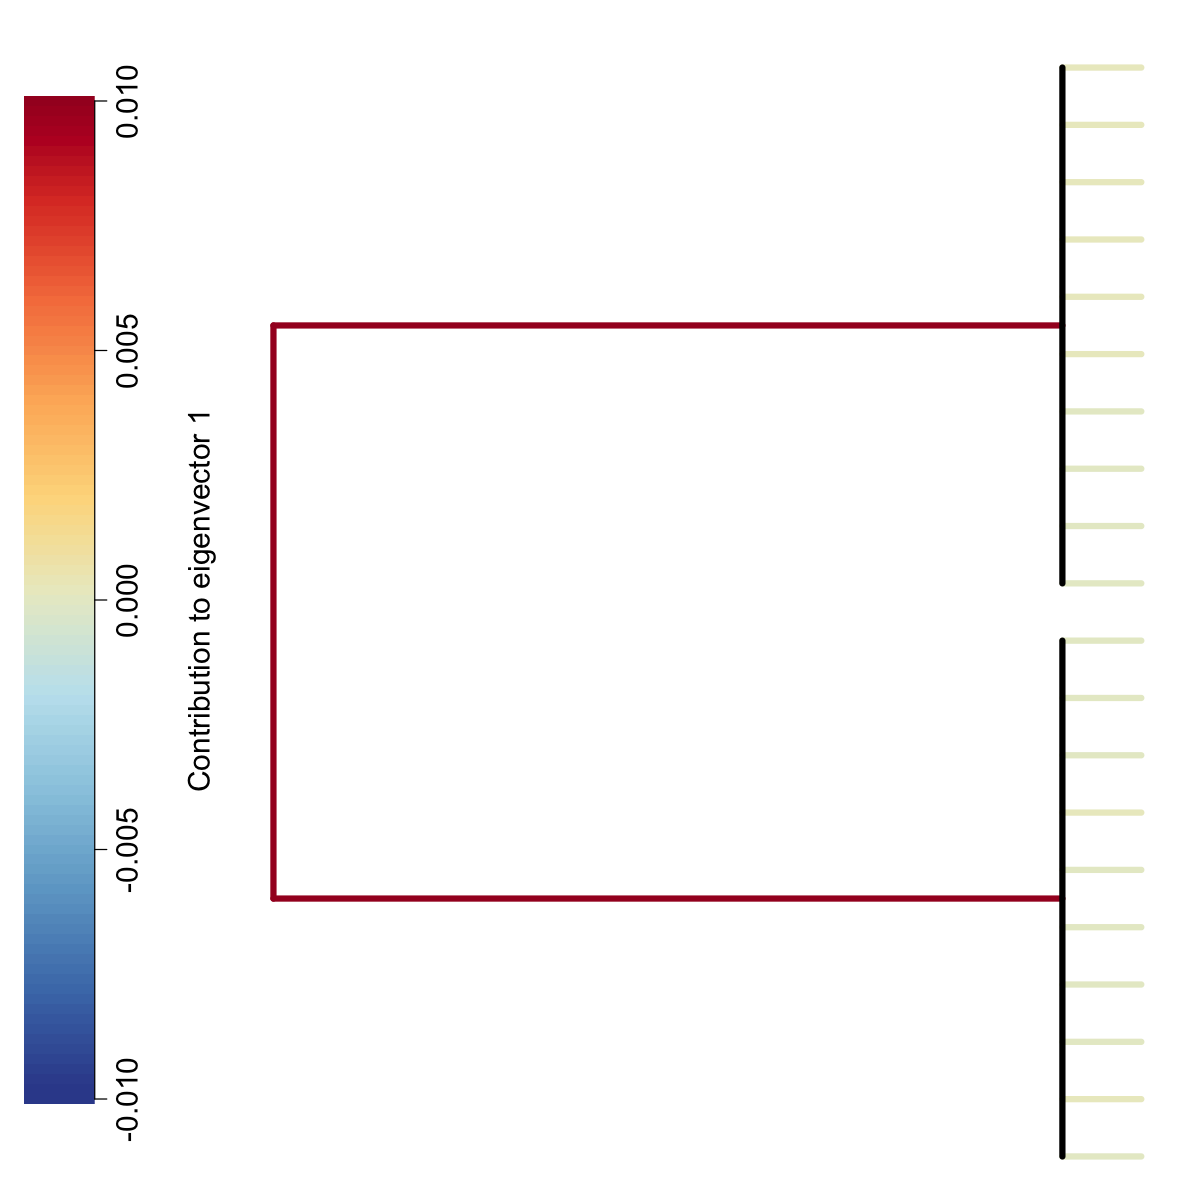

In [11]:
options(repr.plot.width = 10, repr.plot.height = 10)
layout(matrix(1:2, nrow = 1, byrow = TRUE), widths = c(3, 35)) 

par(mar = c(4, 1, 4, 0))
image(x = 1, y = color_breaks_1, z = matrix(color_breaks_1, nrow = 1),
      col = color_palette, axes = FALSE, xlab = "", ylab = "")
axis(4, cex.axis = 1.5)
mtext("Contribution to eigenvector 1", side = 4, line = 4, cex = 1.5)

par(mar = c(0, 6, 1, 1))
plot.phylo(combined_tree, edge.color = branch_colors_felsenstein_dcVCV, 
           edge.width = 5, show.tip.label = FALSE)

In [13]:
svg("Figures_raw/PC_contributions_felsenstein.svg", width = 10, height = 10)
layout(matrix(1:2, nrow = 1, byrow = TRUE), widths = c(3, 35)) 

par(mar = c(4, 1, 4, 0))
image(x = 1, y = color_breaks_1, z = matrix(color_breaks_1, nrow = 1),
      col = color_palette, axes = FALSE, xlab = "", ylab = "")
axis(4, cex.axis = 1.5)
mtext("Contribution to eigenvector 1", side = 4, line = 4, cex = 1.5)

par(mar = c(0, 6, 1, 1))
plot.phylo(combined_tree, edge.color = branch_colors_felsenstein_dcVCV, 
           edge.width = 5, show.tip.label = FALSE)

dev.off()

pdf 
  2

In [14]:
pdf("Figures_raw/PC_contributions_felsenstein.pdf", width = 10, height = 10)
layout(matrix(1:2, nrow = 1, byrow = TRUE), widths = c(3, 35)) 

par(mar = c(4, 1, 4, 0))
image(x = 1, y = color_breaks_1, z = matrix(color_breaks_1, nrow = 1),
      col = color_palette, axes = FALSE, xlab = "", ylab = "")
axis(4, cex.axis = 1.5)
mtext("Contribution to eigenvector 1", side = 4, line = 4, cex = 1.5)

par(mar = c(0, 6, 1, 1))
plot.phylo(combined_tree, edge.color = branch_colors_felsenstein_dcVCV, 
           edge.width = 5, show.tip.label = FALSE)

dev.off()

pdf 
  2

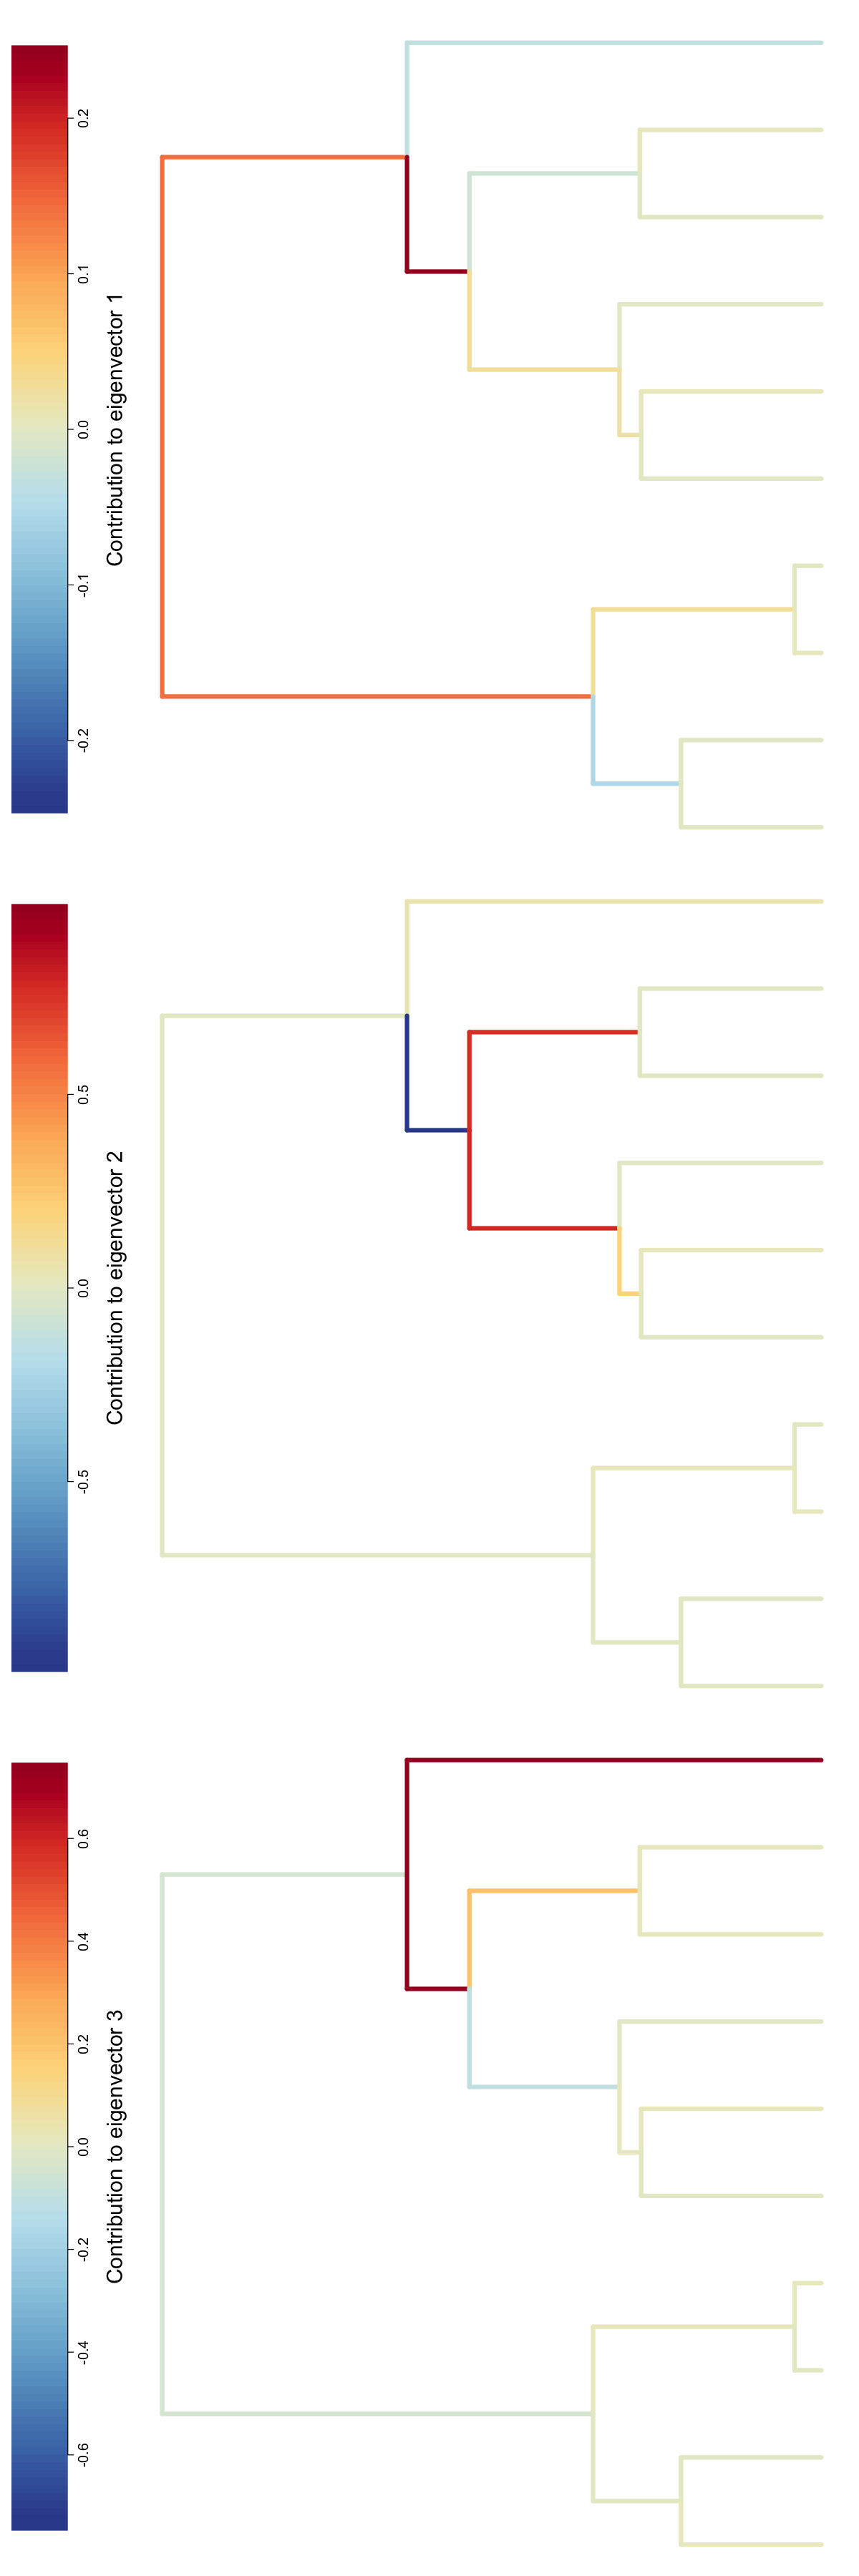

In [15]:
options(repr.plot.width = 10, repr.plot.height = 30)
layout(matrix(1:6, nrow = 3, byrow = TRUE), widths = c(3, 35))

par(mar = c(4, 1, 4, 0))
image(x = 1, y = color_breaks_2_1, z = matrix(color_breaks_2_1, nrow = 1),
      col = color_palette, axes = FALSE, xlab = "", ylab = "")
axis(4, cex.axis = 1.5)
mtext("Contribution to eigenvector 1", side = 4, line = 4, cex = 1.5)

par(mar = c(0, 6, 1, 1))
plot.phylo(yule_tree, edge.color = branch_colors_yule_dcVCV_1, 
           edge.width = 5, show.tip.label = FALSE)

par(mar = c(4, 1, 4, 0))
image(x = 1, y = color_breaks_2_2, z = matrix(color_breaks_2_2, nrow = 1),
      col = color_palette, axes = FALSE, xlab = "", ylab = "")
axis(4, cex.axis = 1.5)
mtext("Contribution to eigenvector 2", side = 4, line = 4, cex = 1.5)

par(mar = c(0, 6, 1, 1))
plot.phylo(yule_tree, edge.color = branch_colors_yule_dcVCV_2, 
           edge.width = 5, show.tip.label = FALSE)

par(mar = c(4, 1, 4, 0))
image(x = 1, y = color_breaks_2_3, z = matrix(color_breaks_2_3, nrow = 1),
      col = color_palette, axes = FALSE, xlab = "", ylab = "")
axis(4, cex.axis = 1.5)
mtext("Contribution to eigenvector 3", side = 4, line = 4, cex = 1.5)

par(mar = c(0, 6, 1, 1))
plot.phylo(yule_tree, edge.color = branch_colors_yule_dcVCV_3, 
           edge.width = 5, show.tip.label = FALSE)

In [16]:
svg("Figures_raw/PC_contributions_yule.svg", width = 10, height = 30)
layout(matrix(1:6, nrow = 3, byrow = TRUE), widths = c(3, 35))

par(mar = c(4, 1, 4, 0))
image(x = 1, y = color_breaks_2_1, z = matrix(color_breaks_2_1, nrow = 1),
      col = color_palette, axes = FALSE, xlab = "", ylab = "")
axis(4, cex.axis = 1.5)
mtext("Contribution to eigenvector 1", side = 4, line = 4, cex = 1.5)

par(mar = c(0, 6, 1, 1))
plot.phylo(yule_tree, edge.color = branch_colors_yule_dcVCV_1, 
           edge.width = 5, show.tip.label = FALSE)

par(mar = c(4, 1, 4, 0))
image(x = 1, y = color_breaks_2_2, z = matrix(color_breaks_2_2, nrow = 1),
      col = color_palette, axes = FALSE, xlab = "", ylab = "")
axis(4, cex.axis = 1.5)
mtext("Contribution to eigenvector 2", side = 4, line = 4, cex = 1.5)

par(mar = c(0, 6, 1, 1))
plot.phylo(yule_tree, edge.color = branch_colors_yule_dcVCV_2, 
           edge.width = 5, show.tip.label = FALSE)

par(mar = c(4, 1, 4, 0))
image(x = 1, y = color_breaks_2_3, z = matrix(color_breaks_2_3, nrow = 1),
      col = color_palette, axes = FALSE, xlab = "", ylab = "")
axis(4, cex.axis = 1.5)
mtext("Contribution to eigenvector 3", side = 4, line = 4, cex = 1.5)

par(mar = c(0, 6, 1, 1))
plot.phylo(yule_tree, edge.color = branch_colors_yule_dcVCV_3, 
           edge.width = 5, show.tip.label = FALSE)

dev.off()

pdf 
  2

In [17]:
pdf("Figures_raw/PC_contributions_yule.pdf", width = 10, height = 30)
layout(matrix(1:6, nrow = 3, byrow = TRUE), widths = c(3, 35))

par(mar = c(4, 1, 4, 0))
image(x = 1, y = color_breaks_2_1, z = matrix(color_breaks_2_1, nrow = 1),
      col = color_palette, axes = FALSE, xlab = "", ylab = "")
axis(4, cex.axis = 1.5)
mtext("Contribution to eigenvector 1", side = 4, line = 4, cex = 1.5)

par(mar = c(0, 6, 1, 1))
plot.phylo(yule_tree, edge.color = branch_colors_yule_dcVCV_1, 
           edge.width = 5, show.tip.label = FALSE)

par(mar = c(4, 1, 4, 0))
image(x = 1, y = color_breaks_2_2, z = matrix(color_breaks_2_2, nrow = 1),
      col = color_palette, axes = FALSE, xlab = "", ylab = "")
axis(4, cex.axis = 1.5)
mtext("Contribution to eigenvector 2", side = 4, line = 4, cex = 1.5)

par(mar = c(0, 6, 1, 1))
plot.phylo(yule_tree, edge.color = branch_colors_yule_dcVCV_2, 
           edge.width = 5, show.tip.label = FALSE)

par(mar = c(4, 1, 4, 0))
image(x = 1, y = color_breaks_2_3, z = matrix(color_breaks_2_3, nrow = 1),
      col = color_palette, axes = FALSE, xlab = "", ylab = "")
axis(4, cex.axis = 1.5)
mtext("Contribution to eigenvector 3", side = 4, line = 4, cex = 1.5)

par(mar = c(0, 6, 1, 1))
plot.phylo(yule_tree, edge.color = branch_colors_yule_dcVCV_3, 
           edge.width = 5, show.tip.label = FALSE)

dev.off()

pdf 
  2